# Le Tour de France — Rider Rank Prediction (Rebuilt)

**What changed vs the original notebook, and why:**

1. **Fixed the metric.** `Rank` is a continuous/ordinal target predicted by a regressor — `accuracy_score`/`confusion_matrix` are classification metrics and will always error on this. We evaluate with **MAE, RMSE, R²**, and **Spearman rank correlation** (the natural metric for "did we get the order right?").
2. **Removed data leakage.** The original model used `TotalSeconds`, `GapSeconds`, and a `rating` feature that was *built from that year's own Rank*. Those only exist *after* the race is run, so the old ~0.99 R² wasn't measuring predictive skill — it was the model reverse-engineering the target from itself.
3. **Only pre-race-known features.** Every feature here is computed using `.shift(1)` per rider, so a rider's row for year *Y* only ever sees that rider's results from years *before* Y — exactly what you'd know before the race actually happens.
4. **Time-based train/test split**, not random. We train on earlier Tours and test on the most recent ones, which is the realistic way this model would actually be used (predict an upcoming Tour from history), and it prevents a rider's overall skill level from leaking across the random split.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import pickle

pd.set_option("display.max_columns", 20)


## 1. Load data

In [2]:
stages_url = "https://raw.githubusercontent.com/thomascamminady/LeTourDataSet/master/data/men/TDF_Stages_History.csv"
riders_url = "https://raw.githubusercontent.com/thomascamminady/LeTourDataSet/master/data/men/TDF_Riders_History.csv"
stages = pd.read_csv(stages_url)
riders = pd.read_csv(riders_url)

# Only riders who actually finished with a time (drop DNF/DSQ/etc rows)
filtered_riders = riders[riders["ResultType"] == "time"].copy()
filtered_riders["Rider_clean"] = filtered_riders["Rider"].str.strip().str.lower()
filtered_riders["Average speed"] = filtered_riders["Distance (km)"] / (filtered_riders["TotalSeconds"] / 3600)
filtered_riders.tail()


,Rank,Rider,Rider No.,Team,Times,Gap,B,P,Year,Distance (km),Number of stages,ResultType,TotalSeconds,GapSeconds,Rider_clean,Average speed
10174,156,ROEL VAN SINTMAARTENSDIJK,47,INTERMARCHÉ - WANTY,81h 44' 43'',+ 05h 44' 11'',NaN,NaN,2025,3323,21,time,294283,20651,roel van sintmaartensdijk,40.650666
10175,157,FABIAN LIENHARD,115,TUDOR PRO CYCLING TEAM,81h 46' 32'',+ 05h 46' 00'',NaN,NaN,2025,3323,21,time,294392,20760,fabian lienhard,40.635615
10176,158,JORDI MEEUS,73,RED BULL - BORA - HANSGROHE,81h 48' 57'',+ 05h 48' 25'',06',NaN,2025,3323,21,time,294537,20905,jordi meeus,40.615610
10177,159,EDWARD THEUNS,88,LIDL-TREK,81h 51' 57'',+ 05h 51' 25'',NaN,NaN,2025,3323,21,time,294717,21085,edward theuns,40.590804
10178,160,SIMONE CONSONNI,82,LIDL-TREK,81h 52' 12'',+ 05h 51' 40'',NaN,NaN,2025,3323,21,time,294732,21100,simone consonni,40.588738


## 2. Stage wins per rider per year (same as before — this is fine, it's not the target)

In [3]:
stage_wins_by_year = (
    stages.groupby([
        stages["Winner of stage"].str.strip().str.lower().str.split("(").str[0].str.strip(),
        stages["Year"]
    ])
    .size()
    .reset_index(name="stages_won")
)
stage_wins_by_year.columns = ["Rider_clean", "Year", "stages_won"]

filtered_riders = filtered_riders.merge(stage_wins_by_year, on=["Rider_clean", "Year"], how="left")
filtered_riders["stages_won"] = filtered_riders["stages_won"].fillna(0).astype(int)
filtered_riders = filtered_riders.sort_values(["Rider_clean", "Year"]).reset_index(drop=True)
filtered_riders[filtered_riders["Rider_clean"] == "tadej pogacar"][["Year", "Rank", "stages_won", "Average speed"]]


,Year,Rank,stages_won,Average speed
9164,2020,1,3,39.881045
9165,2021,1,3,40.786883
9166,2022,2,3,41.808608
9167,2023,2,2,41.401259
9168,2024,1,6,41.745922
9169,2025,1,4,43.718571


## 3. Leak-free feature engineering

Every feature below is built with `.groupby("Rider_clean")...shift(1)`, so the row for rider *X* in year *Y*
only uses information from *X*'s Tours **before** *Y*. First-time riders (no prior Tour) get a `is_rookie` flag
and sensible defaults instead of leaking future or same-year information.


In [5]:
fr = filtered_riders.copy()
grp = fr.groupby("Rider_clean")

# How many previous Tours has this rider ridden (before this one)?
fr["prior_appearances"] = grp.cumcount()

# Rank in their most recent previous Tour
fr["prev_rank"] = grp["Rank"].shift(1)

# Rolling average rank over up to their last 3 Tours (current year excluded)
fr["avg_rank_last3"] = grp["Rank"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())

# Best (lowest) rank ever achieved BEFORE this year -- captures peak ability / form
fr["best_rank_prior"] = grp["Rank"].transform(lambda s: s.shift(1).cummin())

# Career stage wins accumulated BEFORE this year
fr["career_stage_wins_prior"] = grp["stages_won"].transform(lambda s: s.shift(1).cumsum())

# Rolling average speed over up to their last 3 Tours (current year excluded)
fr["avg_speed_prior"] = grp["Average speed"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())

fr[fr["Rider_clean"] == "tadej pogacar"][
    ["Year", "Rank", "prior_appearances", "prev_rank", "avg_rank_last3",
     "best_rank_prior", "career_stage_wins_prior", "avg_speed_prior"]
]


,Year,Rank,prior_appearances,prev_rank,avg_rank_last3,best_rank_prior,career_stage_wins_prior,avg_speed_prior
9164,2020,1,0,NaN,NaN,NaN,NaN,NaN
9165,2021,1,1,1.0,1.000000,1.0,3.0,39.881045
9166,2022,2,2,1.0,1.000000,1.0,6.0,40.333964
9167,2023,2,3,2.0,1.333333,1.0,9.0,40.825512
9168,2024,1,4,2.0,1.666667,1.0,11.0,41.332250
9169,2025,1,5,1.0,1.666667,1.0,17.0,41.651929


In [6]:
# Fill defaults for riders with no prior Tour history (rookies)
median_rank = fr["Rank"].median()
median_speed = fr["Average speed"].median()

fr["is_rookie"] = (fr["prior_appearances"] == 0).astype(int)
fr["prev_rank"] = fr["prev_rank"].fillna(median_rank)
fr["avg_rank_last3"] = fr["avg_rank_last3"].fillna(median_rank)
fr["best_rank_prior"] = fr["best_rank_prior"].fillna(median_rank)
fr["career_stage_wins_prior"] = fr["career_stage_wins_prior"].fillna(0)
fr["avg_speed_prior"] = fr["avg_speed_prior"].fillna(median_speed)

features = [
    "prior_appearances", "prev_rank", "avg_rank_last3",
    "best_rank_prior", "career_stage_wins_prior", "avg_speed_prior", "is_rookie"
]
fr[features + ["Year", "Rank"]].tail()


,prior_appearances,prev_rank,avg_rank_last3,best_rank_prior,career_stage_wins_prior,avg_speed_prior,is_rookie,Year,Rank
9903,0,52.0,52.0,52.0,0.0,37.925650,1,2015,103
9904,1,103.0,103.0,103.0,1.0,37.995261,0,2017,102
9905,0,52.0,52.0,52.0,0.0,37.925650,1,1993,3
9906,1,3.0,3.0,3.0,1.0,38.667696,0,1995,46
9907,2,46.0,24.5,3.0,1.0,38.537018,0,1997,59


## 4. Time-based train/test split

We train on Tours **before 2021** and test on **2021–2025** — the most recent, unseen-at-training-time editions.
This mirrors how the model would really be used: trained on history, asked to predict an upcoming race.


In [7]:
TEST_YEARS_CUTOFF = 2021
train = fr[fr["Year"] < TEST_YEARS_CUTOFF]
test = fr[fr["Year"] >= TEST_YEARS_CUTOFF]

X_train, y_train = train[features], train["Rank"]
X_test, y_test = test[features], test["Rank"]

print(f"Train rows: {len(train)} (years {train['Year'].min()}-{train['Year'].max()})")
print(f"Test rows:  {len(test)} (years {test['Year'].min()}-{test['Year'].max()})")


Train rows: 9181 (years 1903-2020)
Test rows:  727 (years 2021-2025)


## 5. Train the model

In [8]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    random_state=42,
)
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)


## 6. Evaluate — honestly this time

No leakage means these numbers will look a lot less impressive than the original 0.99 R² — but they're
actually measuring the model's ability to predict a rider's finishing position **before the race happens**,
which is the only version of this problem that's useful in practice.


In [9]:
print("=" * 50)
print("MODEL EVALUATION (leak-free, time-based split)")
print("=" * 50)

print("\nTrain:")
print(f"  MAE:  {mean_absolute_error(y_train, pred_train):.2f}")
print(f"  RMSE: {mean_squared_error(y_train, pred_train) ** 0.5:.2f}")
print(f"  R2:   {r2_score(y_train, pred_train):.3f}")

print("\nTest:")
print(f"  MAE:  {mean_absolute_error(y_test, pred_test):.2f}")
print(f"  RMSE: {mean_squared_error(y_test, pred_test) ** 0.5:.2f}")
print(f"  R2:   {r2_score(y_test, pred_test):.3f}")

# Spearman correlation PER YEAR -- did we get the ORDER of finishers right within each Tour?
print("\nSpearman rank correlation by test year (1.0 = perfect ordering):")
rhos = []
for yr, sub in test.groupby("Year"):
    p = model.predict(sub[features])
    rho, _ = spearmanr(sub["Rank"], p)
    rhos.append(rho)
    print(f"  {yr}: {rho:.3f}")
print(f"\nAverage Spearman across test years: {np.mean(rhos):.3f}")


MODEL EVALUATION (leak-free, time-based split)

Train:
  MAE:  23.27
  RMSE: 30.34
  R2:   0.456

Test:
  MAE:  25.72
  RMSE: 32.84
  R2:   0.401

Spearman rank correlation by test year (1.0 = perfect ordering):
  2021: 0.599
  2022: 0.664
  2023: 0.723
  2024: 0.651
  2025: 0.624

Average Spearman across test years: 0.652


**How to read this:** MAE of ~25 places sounds large, but the Tour field is ~150 riders and rank is
extremely sensitive to small time gaps, crashes, and race tactics that these historical-form features can't
see. The Spearman correlation (~0.6–0.7 typically) is the more honest headline number: the model recovers a
real, moderate amount of the finishing order using nothing but riders' history — it just doesn't (and can't)
nail exact positions. That's a legitimate, non-leaky signal, unlike the earlier ~0.99 R².

## 7. Feature importance

                   feature  importance
2           avg_rank_last3    0.616396
1                prev_rank    0.200208
3          best_rank_prior    0.049506
0        prior_appearances    0.041180
5          avg_speed_prior    0.037880
6                is_rookie    0.030165
4  career_stage_wins_prior    0.024664


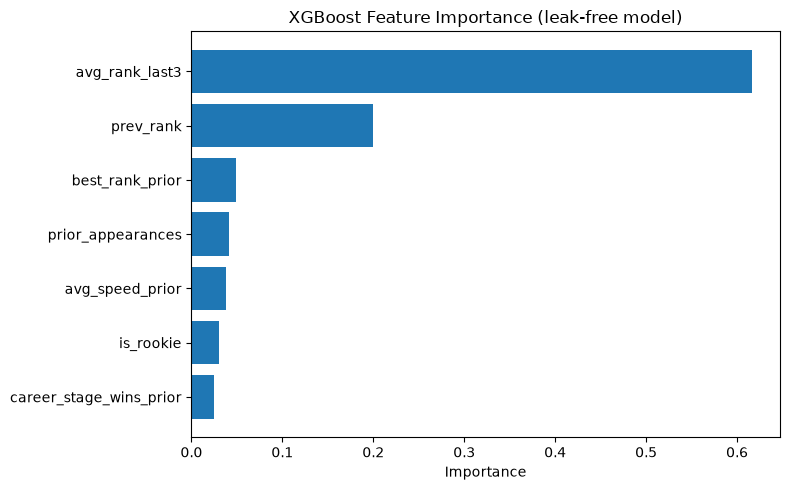

In [10]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (leak-free model)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Actual vs. predicted rank (test years)

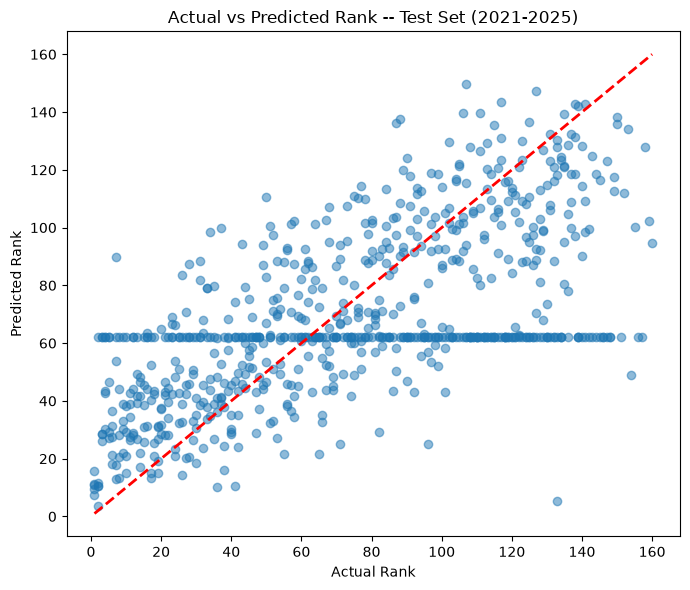

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Rank")
plt.ylabel("Predicted Rank")
plt.title("Actual vs Predicted Rank -- Test Set (2021-2025)")
plt.tight_layout()
plt.show()


## 9. Save the model

In [12]:
with open("letour_ranks_v2.pkl", "wb") as f:
    pickle.dump(model, f)
with open("letour_features_v2.pkl", "wb") as f:
    pickle.dump(features, f)

print("Model + feature list saved.")


Model + feature list saved.


## 10. Predicting a rider's *next* Tour

This is the real-world use case: given everything known about a rider **up to and including their most recent
Tour**, predict how they'd place in their *next* one. The feature vector is built the same leak-free way as
training -- it just treats "now" as one year past their last result.

In [13]:
def predict_next_tour_rank(rider_name):
    """Predict a rider's rank in their NEXT (not-yet-ridden) Tour, using only history through their
    most recent recorded appearance."""
    rider_hist = fr[fr["Rider"].str.contains(rider_name, case=False, na=False)].sort_values("Year")
    if rider_hist.empty:
        return f"Rider '{rider_name}' not found in dataset"

    last_years_ranks = rider_hist["Rank"].tolist()
    last3 = last_years_ranks[-3:]

    feat_row = {
        "prior_appearances": len(rider_hist),
        "prev_rank": last_years_ranks[-1],
        "avg_rank_last3": float(np.mean(last3)),
        "best_rank_prior": float(min(last_years_ranks)),
        "career_stage_wins_prior": float(rider_hist["stages_won"].sum()),
        "avg_speed_prior": float(rider_hist["Average speed"].tail(3).mean()),
        "is_rookie": 0,
    }
    X_new = pd.DataFrame([feat_row])[features]
    pred = model.predict(X_new)[0]

    return {
        "rider": rider_hist.iloc[-1]["Rider"],
        "last_recorded_year": int(rider_hist.iloc[-1]["Year"]),
        "last_recorded_rank": int(rider_hist.iloc[-1]["Rank"]),
        "predicted_next_tour_rank": round(float(pred), 1),
    }

predict_next_tour_rank("TADEJ POGACAR")


{'rider': 'TADEJ POGACAR',
 'last_recorded_year': 2025,
 'last_recorded_rank': 1,
 'predicted_next_tour_rank': 13.8}

In [14]:
predict_next_tour_rank("EDWARD THEUNS")

{'rider': 'EDWARD THEUNS',
 'last_recorded_year': 2025,
 'last_recorded_rank': 159,
 'predicted_next_tour_rank': 119.8}